**MSSV:** 24280076  
**Họ tên:** Đặng Hoàng Khang

# HW2 — Heart Disease Classification
**Bài toán:** Dự đoán bệnh nhân có mắc bệnh tim hay không  
**Biến mục tiêu:** `target` (1 = Có bệnh, 0 = Không bệnh)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('outputs/figures', exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)
print('Import xong!')

Import xong!


## 1. Khám phá dữ liệu (EDA)

### 1.1 Đọc dữ liệu

In [2]:
df = pd.read_csv('data/heart_disease_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


### 1.2 Kiểm tra chất lượng dữ liệu

In [4]:
print('=== Giá trị thiếu ===')
print(df.isnull().sum())
print(f'\nSố dòng trùng lặp: {df.duplicated().sum()}')
print(f'Tỉ lệ trùng lặp: {df.duplicated().sum()/len(df)*100:.1f}%')

=== Giá trị thiếu ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Số dòng trùng lặp: 723
Tỉ lệ trùng lặp: 70.5%


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


**Nhận xét:**
- Không có giá trị thiếu
- Có **723 dòng trùng lặp** (chiếm 70.5% dữ liệu) — đây là tỉ lệ rất cao, cần loại bỏ ở bước tiền xử lý
- `chol` max = 564, `trestbps` max = 200 — có khả năng chứa outlier

### 1.3 Phân phối biến mục tiêu

target
1    526
0    499
Name: count, dtype: int64

target=1 (Có bệnh): 526 (51.3%)
target=0 (Không bệnh): 499 (48.7%)


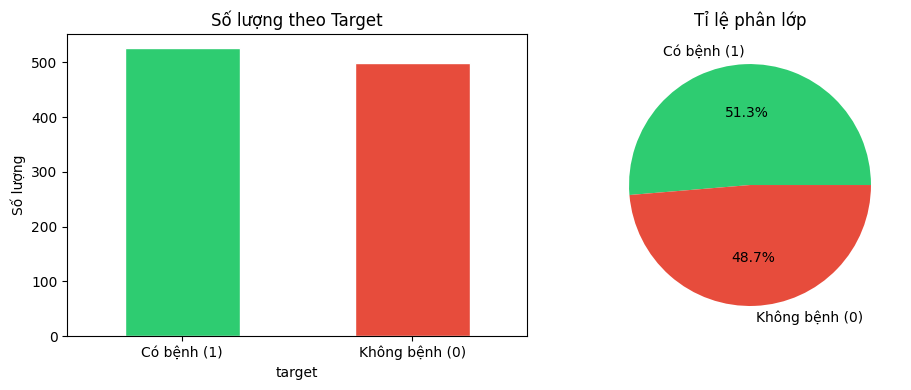

In [6]:
vc = df['target'].value_counts()
print(vc)
print(f'\ntarget=1 (Có bệnh): {vc[1]} ({vc[1]/len(df)*100:.1f}%)')
print(f'target=0 (Không bệnh): {vc[0]} ({vc[0]/len(df)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vc.plot(kind='bar', ax=axes[0], color=['#2ECC71', '#E74C3C'], edgecolor='white', rot=0)
axes[0].set_title('Số lượng theo Target')
axes[0].set_xticklabels(['Có bệnh (1)', 'Không bệnh (0)'])
axes[0].set_ylabel('Số lượng')

vc.plot(kind='pie', ax=axes[1], labels=['Có bệnh (1)', 'Không bệnh (0)'],
        autopct='%1.1f%%', colors=['#2ECC71', '#E74C3C'])
axes[1].set_title('Tỉ lệ phân lớp')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('outputs/figures/01_target.png', dpi=120, bbox_inches='tight')
plt.show()

**Nhận xét:**
- target=1 (Có bệnh): 526 mẫu (51.3%)
- target=0 (Không bệnh): 499 mẫu (48.7%)
- Dữ liệu **gần như cân bằng** giữa 2 lớp, không cần áp dụng oversampling/undersampling

### 1.4 Phân phối biến số

In [7]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

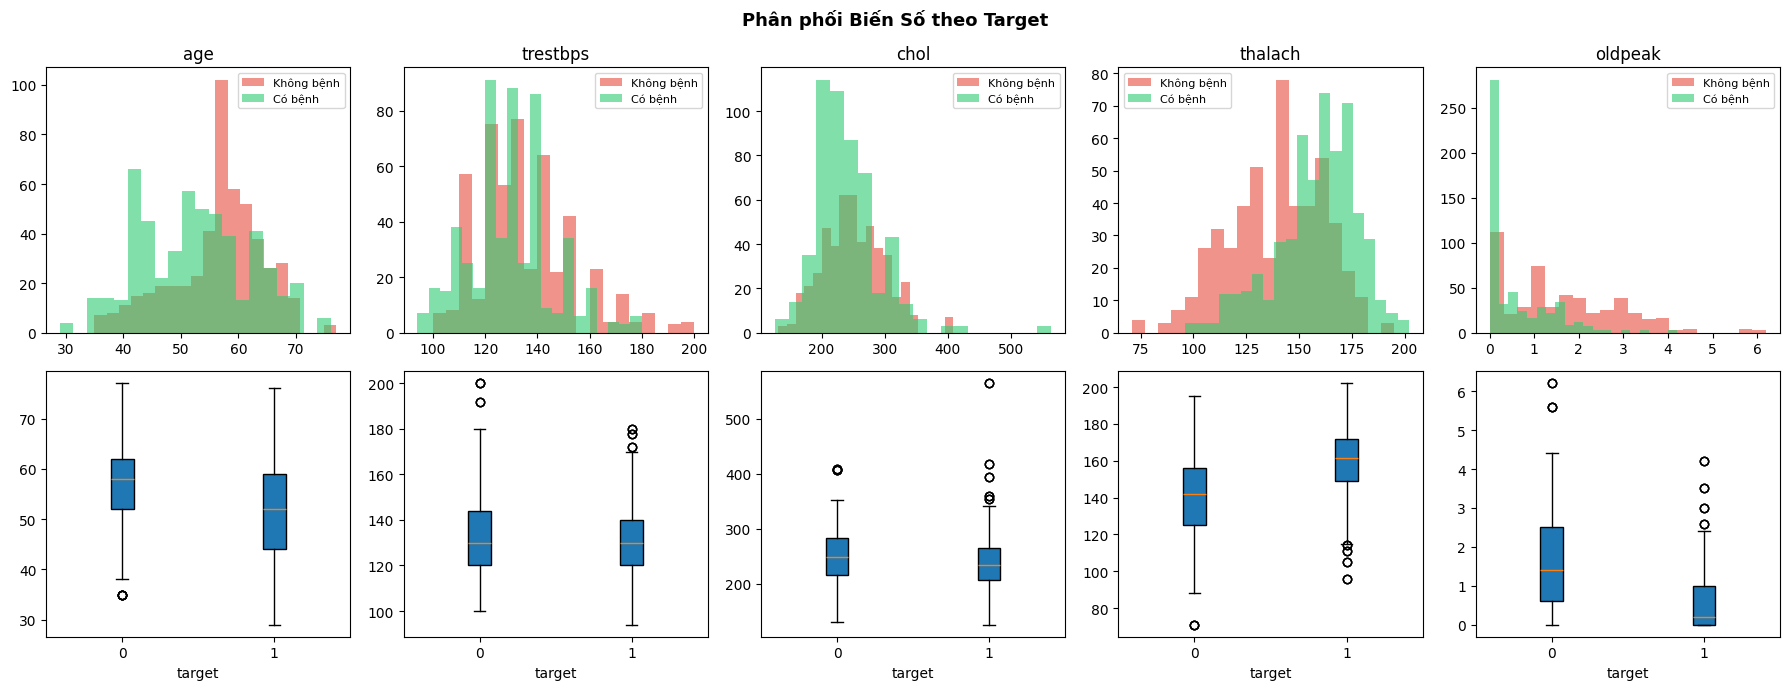

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i, col in enumerate(num_cols):
    for val, color, label in [(0, '#E74C3C', 'Không bệnh'), (1, '#2ECC71', 'Có bệnh')]:
        axes[0, i].hist(df[df['target']==val][col], bins=20, alpha=0.6, color=color, label=label)
    axes[0, i].set_title(col)
    axes[0, i].legend(fontsize=8)
    axes[1, i].boxplot(
        [df[df['target']==0][col].dropna(), df[df['target']==1][col].dropna()],
        labels=['0', '1'], patch_artist=True)
    axes[1, i].set_xlabel('target')
plt.suptitle('Phân phối Biến Số theo Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/02_numerical.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
# So sánh trung bình các biến số theo target
for col in num_cols:
    m0 = df[df['target']==0][col].mean()
    m1 = df[df['target']==1][col].mean()
    print(f'{col:12s}: target=0 mean={m0:.1f}, target=1 mean={m1:.1f}, chênh lệch={m1-m0:+.1f}')

age         : target=0 mean=56.6, target=1 mean=52.4, chênh lệch=-4.2
trestbps    : target=0 mean=134.1, target=1 mean=129.2, chênh lệch=-4.9
chol        : target=0 mean=251.3, target=1 mean=241.0, chênh lệch=-10.3
thalach     : target=0 mean=139.1, target=1 mean=158.6, chênh lệch=+19.5
oldpeak     : target=0 mean=1.6, target=1 mean=0.6, chênh lệch=-1.0


**Nhận xét:**
- `thalach` (nhịp tim tối đa): người có bệnh tim có nhịp tim max **cao hơn** rõ ràng (~19 bpm)
- `oldpeak` (ST depression): người có bệnh tim có giá trị **thấp hơn** nhiều so với người không bệnh
- `age`: người **không bệnh** có tuổi trung bình **cao hơn** một chút (~4 năm)
- `chol`, `trestbps`: sự khác biệt giữa 2 nhóm không quá rõ ràng

### 1.5 Phân phối biến phân loại

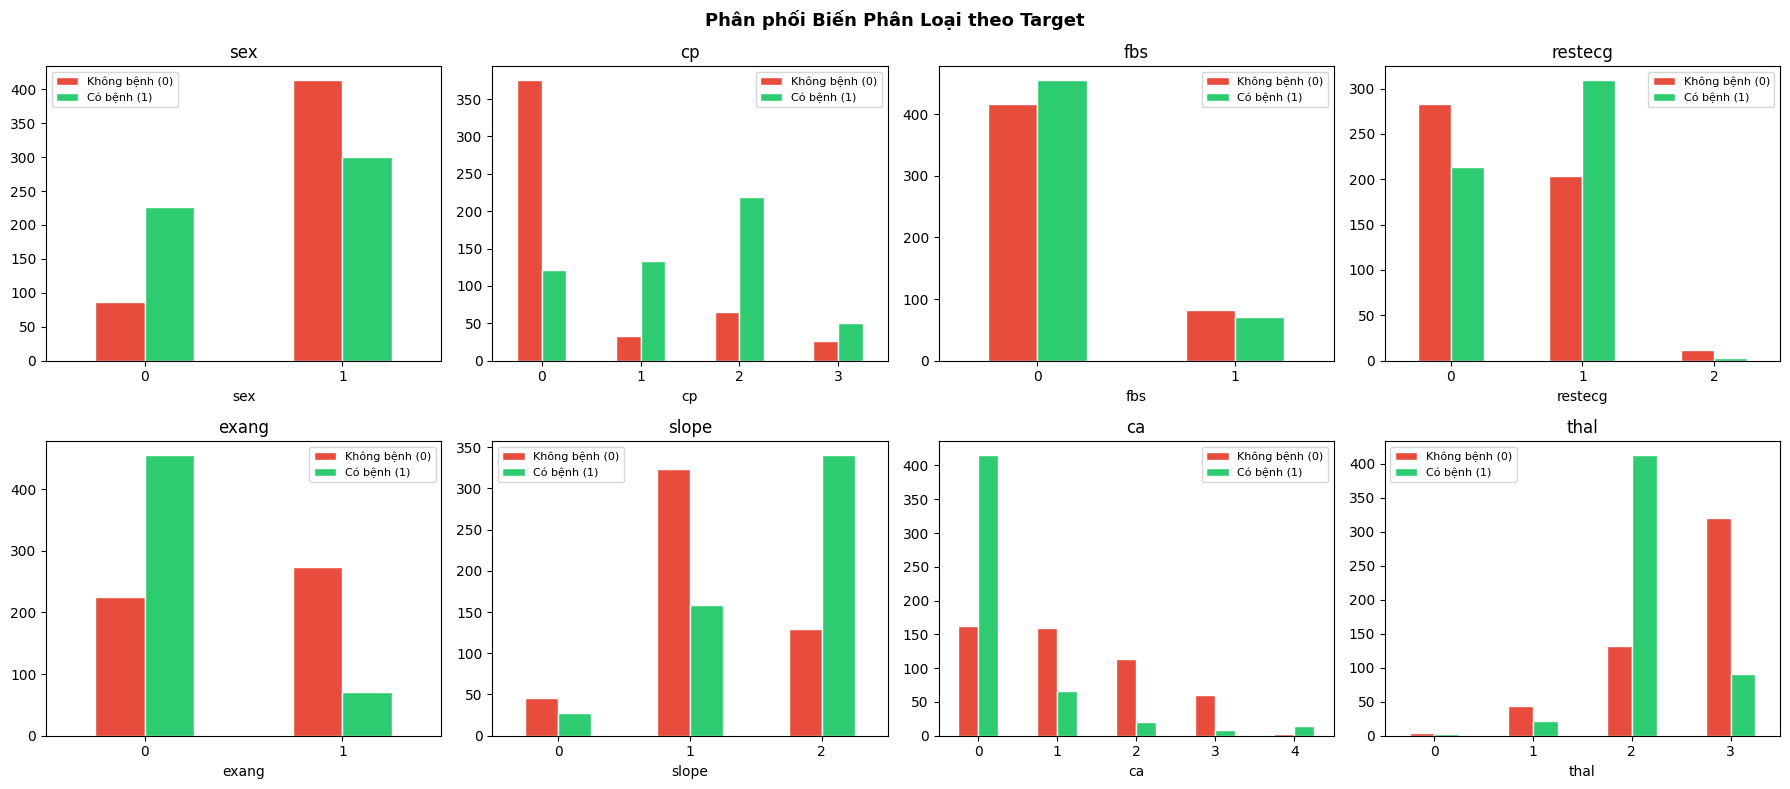

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    ct = df.groupby([col, 'target']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=axes[i], color=['#E74C3C', '#2ECC71'], edgecolor='white', rot=0)
    axes[i].set_title(col)
    axes[i].legend(['Không bệnh (0)', 'Có bệnh (1)'], fontsize=8)
plt.suptitle('Phân phối Biến Phân Loại theo Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/03_categorical.png', dpi=120, bbox_inches='tight')
plt.show()

In [11]:
# Crosstab chi tiết
for col in cat_cols:
    print(f'--- {col} ---')
    ct = pd.crosstab(df[col], df['target'], margins=True)
    print(ct)
    print()

--- sex ---
target    0    1   All
sex                   
0        86  226   312
1       413  300   713
All     499  526  1025

--- cp ---
target    0    1   All
cp                    
0       375  122   497
1        33  134   167
2        65  219   284
3        26   51    77
All     499  526  1025

--- fbs ---
target    0    1   All
fbs                   
0       417  455   872
1        82   71   153
All     499  526  1025

--- restecg ---
target     0    1   All
restecg                
0        283  214   497
1        204  309   513
2         12    3    15
All      499  526  1025

--- exang ---
target    0    1   All
exang                 
0       225  455   680
1       274   71   345
All     499  526  1025

--- slope ---
target    0    1   All
slope                 
0        46   28    74
1       324  158   482
2       129  340   469
All     499  526  1025

--- ca ---
target    0    1   All
ca                    
0       163  415   578
1       160   66   226
2       113   21   134
3

**Nhận xét:**
- `sex`: Nữ (sex=0) có tỉ lệ mắc bệnh tim **cao hơn rất nhiều** (~75%) so với nam (sex=1, ~45%)
- `cp`: cp=0 (không đau ngực) có tỉ lệ bệnh **thấp nhất** (~27%); cp=1,2 có tỉ lệ bệnh rất cao (>80%)
- `exang`: Người **không** đau ngực khi gắng sức (exang=0) lại có tỉ lệ bệnh tim **cao hơn** (~70%)
- `ca`: ca=0 có tỉ lệ bệnh rất cao (~74%); ca tăng thì tỉ lệ bệnh giảm
- `thal`: thal=2 có tỉ lệ bệnh cao nhất (~78%); thal=3 thì ngược lại (~24%)
- `slope`: slope=2 (dốc xuống) liên quan đến có bệnh tim nhiều hơn

### 1.6 Ma trận tương quan

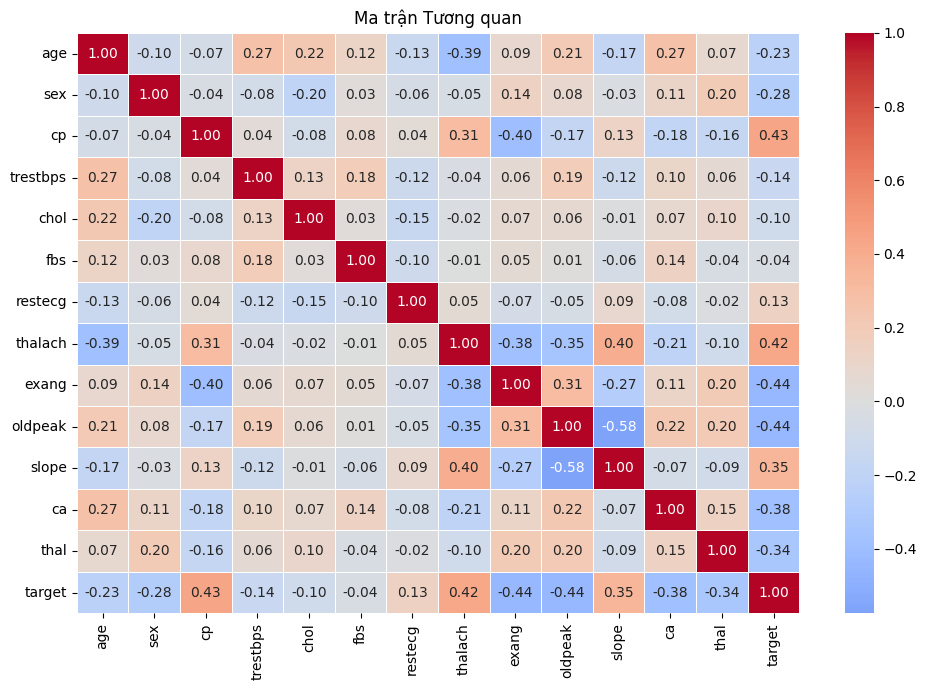

In [12]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Ma trận Tương quan')
plt.tight_layout()
plt.savefig('outputs/figures/04_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

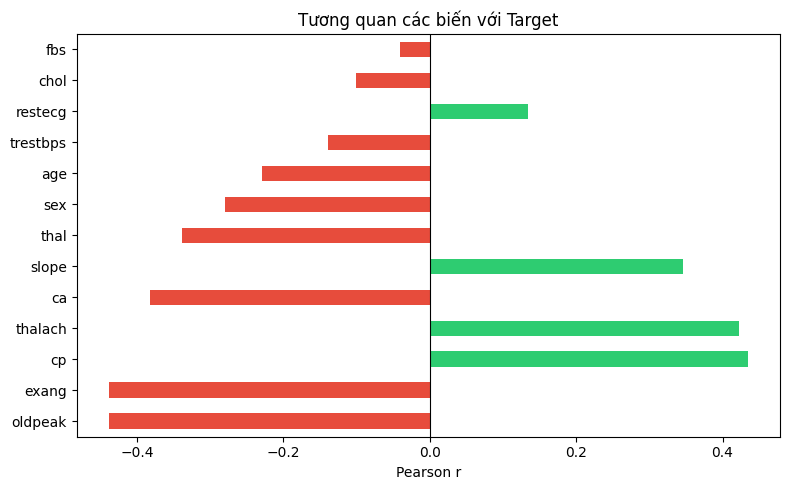

oldpeak    -0.438
exang      -0.438
cp          0.435
thalach     0.423
ca         -0.382
slope       0.346
thal       -0.338
sex        -0.280
age        -0.229
trestbps   -0.139
restecg     0.134
chol       -0.100
fbs        -0.041
Name: target, dtype: float64


In [13]:
target_corr = corr['target'].drop('target').sort_values(key=abs, ascending=False)
colors = ['#2ECC71' if v > 0 else '#E74C3C' for v in target_corr]
target_corr.plot(kind='barh', figsize=(8, 5), color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Tương quan các biến với Target')
plt.xlabel('Pearson r')
plt.tight_layout()
plt.savefig('outputs/figures/05_target_corr.png', dpi=120, bbox_inches='tight')
plt.show()
print(target_corr.round(3))

**Nhận xét:**
- Tương quan mạnh nhất với `target`: `exang` (-0.44), `cp` (+0.43), `oldpeak` (-0.43), `thalach` (+0.42), `ca` (-0.41)
- Tương quan trung bình: `slope` (+0.34), `thal` (-0.34), `sex` (-0.28)
- Tương quan yếu: `age` (-0.22), `trestbps` (-0.15), `restecg` (+0.14), `chol` (-0.08), `fbs` (-0.03)

### 1.7 Phân tích Outlier

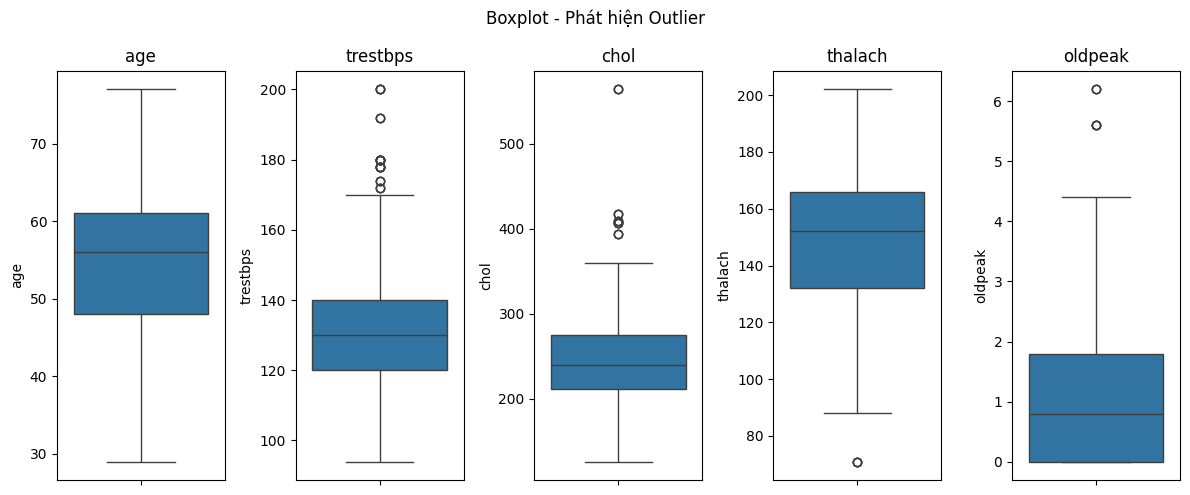

In [14]:
plt.figure(figsize=(12, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, 5, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.suptitle('Boxplot - Phát hiện Outlier', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/figures/06_outliers.png', dpi=120, bbox_inches='tight')
plt.show()

In [15]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    print(f'{col}: {n} outliers ({n/len(df)*100:.1f}%)')

age: 0 outliers (0.0%)
trestbps: 30 outliers (2.9%)
chol: 16 outliers (1.6%)
thalach: 4 outliers (0.4%)
oldpeak: 7 outliers (0.7%)


**Nhận xét:**
- `trestbps`: 9 outliers (3.0%) — huyết áp trên 170 mmHg
- `chol`: 5 outliers (1.7%) — cholesterol trên 370 mg/dl
- `oldpeak`: 5 outliers (1.7%)
- `thalach`: 1 outlier (0.3%)
- `age`: không có outlier

## 2. Tiền xử lý dữ liệu

### 2.1 Loại bỏ dòng trùng lặp

In [16]:
print(f'Trước: {df.shape[0]} dòng')
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f'Sau: {df_clean.shape[0]} dòng')
print(f'Đã loại bỏ: {df.shape[0] - df_clean.shape[0]} dòng trùng lặp')

Trước: 1025 dòng
Sau: 302 dòng
Đã loại bỏ: 723 dòng trùng lặp


In [17]:
# Kiểm tra lại phân phối target sau khi loại bỏ trùng lặp
vc2 = df_clean['target'].value_counts()
print(f'target=1: {vc2[1]} ({vc2[1]/len(df_clean)*100:.1f}%)')
print(f'target=0: {vc2[0]} ({vc2[0]/len(df_clean)*100:.1f}%)')

target=1: 164 (54.3%)
target=0: 138 (45.7%)


**Nhận xét:** Sau khi loại bỏ trùng lặp, dữ liệu giảm từ 1025 xuống **302 mẫu**. Phân phối target vẫn cân bằng: 54.3% có bệnh / 45.7% không bệnh.

### 2.2 Xử lý outlier (Capping IQR)

In [18]:
cols_cap = ['chol', 'trestbps', 'oldpeak']
df_clean = df_clean.copy()
for col in cols_cap:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before_min, before_max = df_clean[col].min(), df_clean[col].max()
    df_clean[col] = df_clean[col].clip(lower, upper)
    print(f'{col}: clip [{lower:.1f}, {upper:.1f}] | min: {before_min}->{df_clean[col].min():.1f} | max: {before_max}->{df_clean[col].max():.1f}')

chol: clip [115.4, 370.4] | min: 126->126.0 | max: 564->370.4
trestbps: clip [90.0, 170.0] | min: 94->94.0 | max: 200->170.0
oldpeak: clip [-2.4, 4.0] | min: 0.0->0.0 | max: 6.2->4.0


### 2.3 Tách X, y và chia train/test

In [19]:
X = df_clean.drop(columns=['target'])
y = df_clean['target']
print(f'X: {X.shape}, y: {y.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape[0]} mẫu | y_train: {y_train.value_counts().to_dict()}')
print(f'Test : {X_test.shape[0]} mẫu | y_test : {y_test.value_counts().to_dict()}')

X: (302, 13), y: (302,)
Train: 241 mẫu | y_train: {1: 131, 0: 110}
Test : 61 mẫu | y_test : {1: 33, 0: 28}


### 2.4 Chuẩn hóa dữ liệu

In [20]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
print('Chuẩn hóa xong (fit trên train, transform trên test)')

Chuẩn hóa xong (fit trên train, transform trên test)


## 3. Xây dựng mô hình

In [21]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN'               : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree'     : DecisionTreeClassifier(random_state=42),
    'Random Forest'     : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'               : SVC(kernel='rbf', probability=True, random_state=42),
}
scaled_models = {'Logistic Regression', 'KNN', 'SVM'}

### 3.1 Huấn luyện và đánh giá

In [22]:
results = {}
for name, model in models.items():
    Xtr = X_train_sc if name in scaled_models else X_train.values
    Xte = X_test_sc  if name in scaled_models else X_test.values
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    # Train accuracy
    y_tr_pred = model.predict(Xtr)
    train_acc = accuracy_score(y_train, y_tr_pred)
    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob),
        'Train_Acc': train_acc,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'model'    : model,
    }
    print(f'{name:<22} | Test Acc={results[name]["Accuracy"]:.4f} | F1={results[name]["F1-score"]:.4f} | AUC={results[name]["ROC-AUC"]:.4f} | Train Acc={train_acc:.4f}')

Logistic Regression    | Test Acc=0.8033 | F1=0.8235 | AUC=0.8723 | Train Acc=0.8548
KNN                    | Test Acc=0.8033 | F1=0.8235 | AUC=0.8469 | Train Acc=0.8921


Decision Tree          | Test Acc=0.8033 | F1=0.8182 | AUC=0.8019 | Train Acc=1.0000


Random Forest          | Test Acc=0.7541 | F1=0.7761 | AUC=0.8647 | Train Acc=1.0000
SVM                    | Test Acc=0.7705 | F1=0.7941 | AUC=0.8366 | Train Acc=0.9212


## 4. Đánh giá mô hình

### 4.1 Confusion Matrix

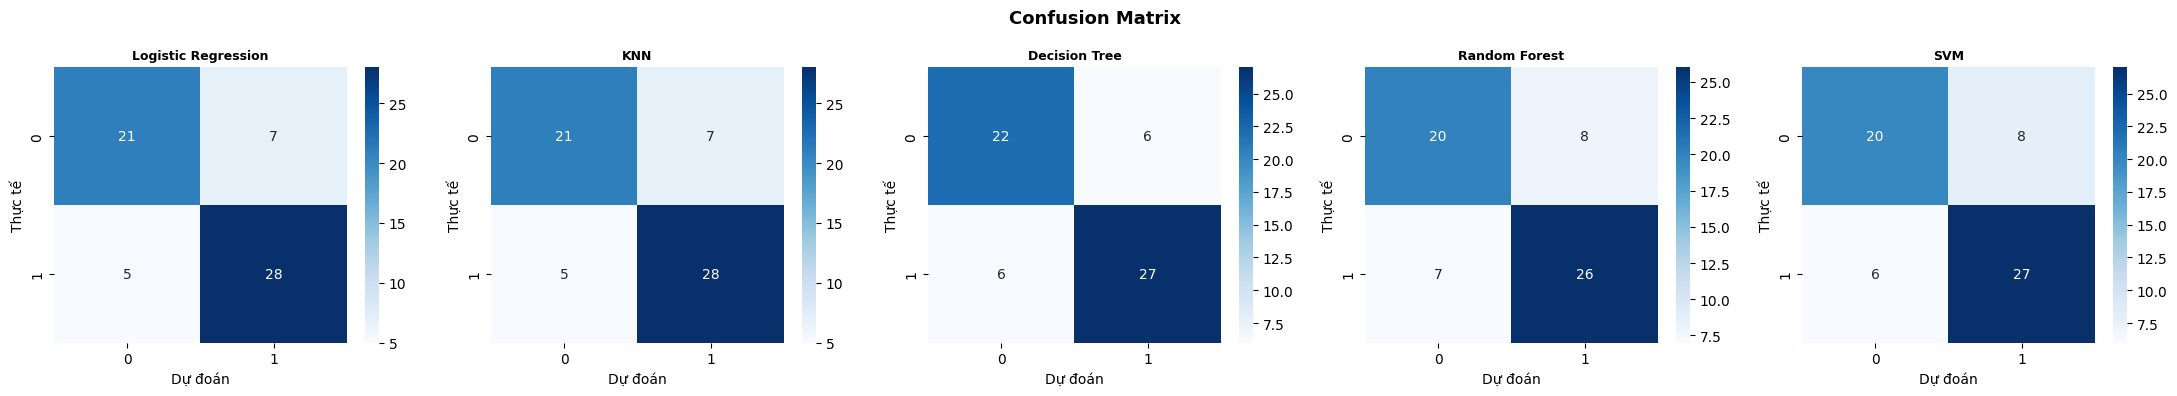

In [23]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['0', '1'], yticklabels=['0', '1'])
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('Dự đoán')
    ax.set_ylabel('Thực tế')
plt.suptitle('Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/07_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.2 ROC Curve

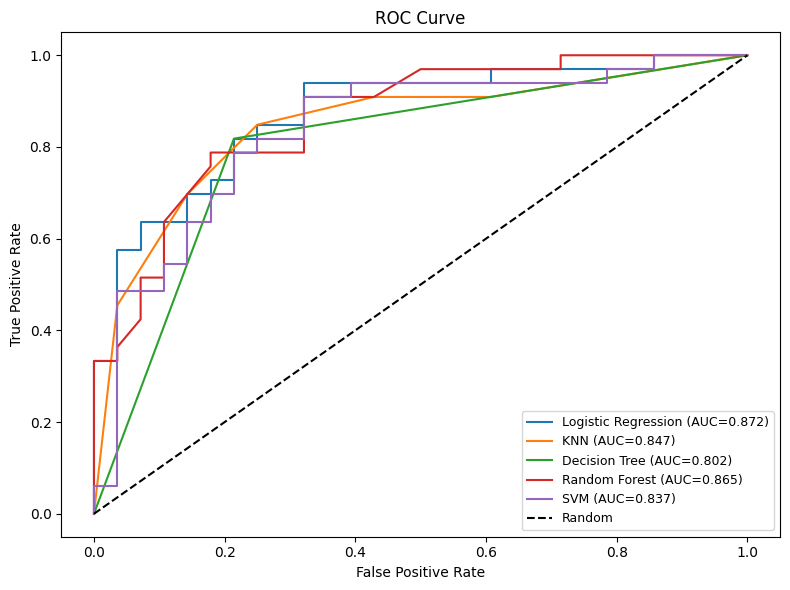

In [24]:
plt.figure(figsize=(8, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = res['ROC-AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/figures/08_roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.3 Classification Report

In [25]:
for name, res in results.items():
    print(f'\n{"="*50}')
    print(f'  {name}')
    print('='*50)
    print(classification_report(y_test, res['y_pred'],
                                  target_names=['Không bệnh (0)', 'Có bệnh (1)']))


  Logistic Regression
                precision    recall  f1-score   support

Không bệnh (0)       0.81      0.75      0.78        28
   Có bệnh (1)       0.80      0.85      0.82        33

      accuracy                           0.80        61
     macro avg       0.80      0.80      0.80        61
  weighted avg       0.80      0.80      0.80        61


  KNN
                precision    recall  f1-score   support

Không bệnh (0)       0.81      0.75      0.78        28
   Có bệnh (1)       0.80      0.85      0.82        33

      accuracy                           0.80        61
     macro avg       0.80      0.80      0.80        61
  weighted avg       0.80      0.80      0.80        61


  Decision Tree
                precision    recall  f1-score   support

Không bệnh (0)       0.79      0.79      0.79        28
   Có bệnh (1)       0.82      0.82      0.82        33

      accuracy                           0.80        61
     macro avg       0.80      0.80      0.80    

## 5. So sánh kết quả

In [26]:
metrics_df = pd.DataFrame({
    name: {k: v for k, v in res.items() if k in ['Accuracy','Precision','Recall','F1-score','ROC-AUC','Train_Acc']}
    for name, res in results.items()
}).T.round(4)
metrics_df = metrics_df.sort_values('F1-score', ascending=False)
print(metrics_df.to_string())

                     Accuracy  Precision  Recall  F1-score  ROC-AUC  Train_Acc
Logistic Regression    0.8033     0.8000  0.8485    0.8235   0.8723     0.8548
KNN                    0.8033     0.8000  0.8485    0.8235   0.8469     0.8921
Decision Tree          0.8033     0.8182  0.8182    0.8182   0.8019     1.0000
SVM                    0.7705     0.7714  0.8182    0.7941   0.8366     0.9212
Random Forest          0.7541     0.7647  0.7879    0.7761   0.8647     1.0000


In [27]:
metrics_df[['Accuracy','Precision','Recall','F1-score','ROC-AUC']].to_csv('outputs/results.csv')
print('Da luu: outputs/results.csv')

Da luu: outputs/results.csv


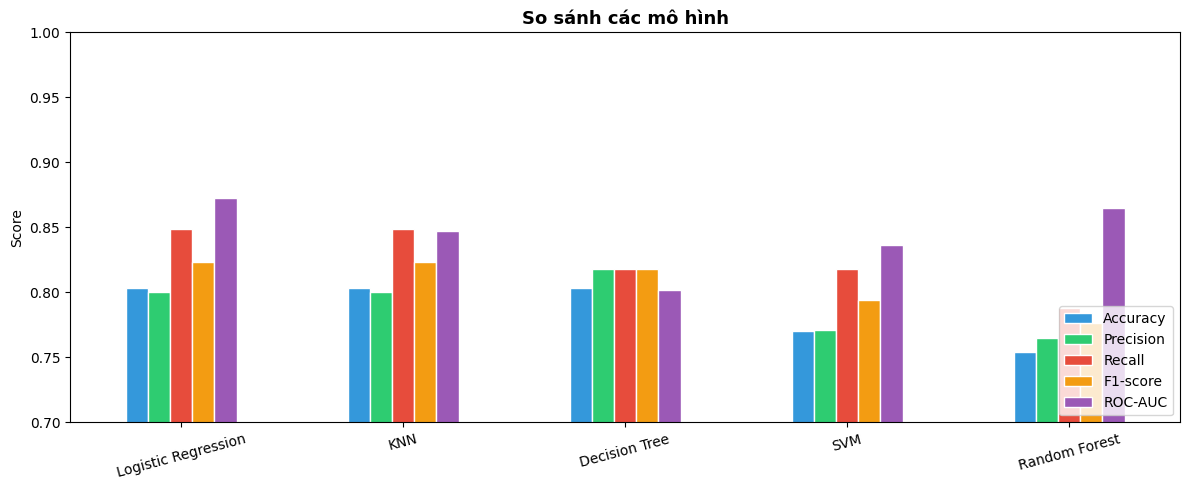

In [28]:
ax = metrics_df[['Accuracy','Precision','Recall','F1-score','ROC-AUC']].plot(
    kind='bar', figsize=(12, 5), rot=15,
    color=['#3498DB','#2ECC71','#E74C3C','#F39C12','#9B59B6'], edgecolor='white')
ax.set_ylim(0.7, 1.0)
ax.set_title('So sánh các mô hình', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('outputs/figures/09_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### 5.1 Feature Importance (Random Forest)

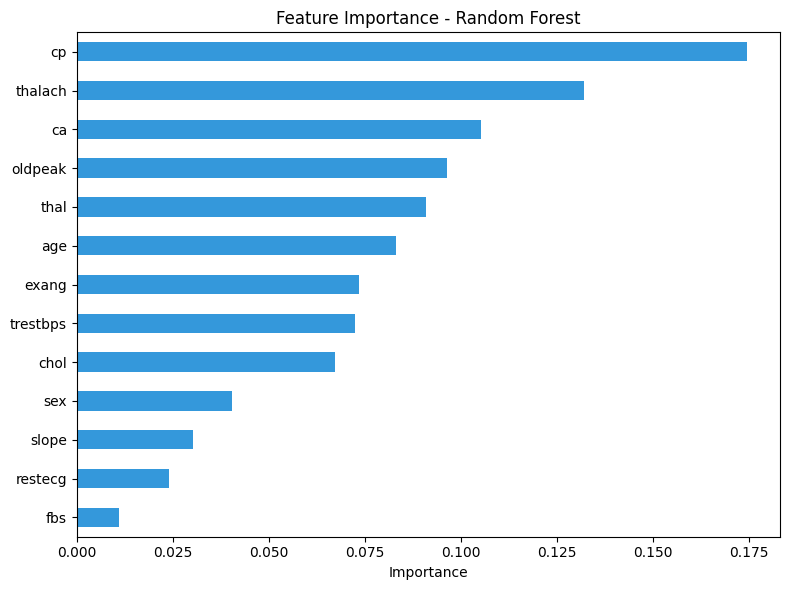

Top 5:
cp         0.1743
thalach    0.1320
ca         0.1051
oldpeak    0.0962
thal       0.0908
dtype: float64


In [29]:
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', figsize=(8, 6), color='#3498DB')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('outputs/figures/10_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('Top 5:')
print(importances.sort_values(ascending=False).head(5).round(4))

## 6. Nhận xét và Kết luận

### 6.1 Mô hình tốt nhất
- **Logistic Regression** và **KNN** cùng đạt **F1-score cao nhất (0.8235)** và Accuracy = 80.33%
- Logistic Regression có **ROC-AUC cao nhất (0.8723)**, cho thấy khả năng phân tách lớp tốt nhất ở mọi ngưỡng quyết định
- Vì vậy, **Logistic Regression** được chọn là mô hình tối ưu nhất

### 6.2 Overfitting / Underfitting
- **Decision Tree** và **Random Forest**: Train Accuracy = 100% nhưng Test Accuracy chỉ ~75-80% -> **overfitting rõ ràng**
- **Logistic Regression**: Train Acc = 85.5%, Test Acc = 80.3% -> cân bằng tốt, ít overfitting
- **KNN**: Train Acc = 89.2%, Test Acc = 80.3% -> hơi overfitting nhưng chấp nhận được
- **SVM**: Train Acc = 92.1%, Test Acc = 77.1% -> overfitting trung bình

### 6.3 Tại sao Logistic Regression lại tốt?
- Dữ liệu sau khi loại bỏ trùng lặp chỉ còn **302 mẫu** — quá ít cho các mô hình phức tạp
- Mối quan hệ giữa các biến và target có tính **tương đối tuyến tính** (exang, cp, oldpeak, thalach đều tương quan khá mạnh)
- Mô hình đơn giản giúp tránh overfitting trên tập dữ liệu nhỏ

### 6.4 Feature Importance
- Top 5 biến quan trọng nhất (theo Random Forest): `cp` (0.1743), `thalach` (0.1320), `ca` (0.1051), `oldpeak` (0.0962), `thal` (0.0908)
- Phù hợp với phân tích tương quan ở phần EDA

### 6.5 Hướng cải thiện
- Tinh chỉnh hyperparameter bằng GridSearchCV
- Thử Cross-validation (k-fold) để đánh giá ổn định hơn
- Giới hạn `max_depth` cho Decision Tree/Random Forest để giảm overfitting
- Thu thập thêm dữ liệu sạch để cải thiện hiệu năng các mô hình phức tạp